In [1]:
#Importing libraries
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
!pip install dmba
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns
from dmba import classificationSummary, gainsChart, liftChart
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import classification_report

Colab environment detected.


In [2]:
data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Python Course/Electronic_sales_Sep2023-Sep2024.csv")

In [3]:
data

,Customer ID,Age,Gender,Loyalty Member,Product Type,SKU,Rating,Order Status,Payment Method,Total Price,Unit Price,Quantity,Purchase Date,Shipping Type,Add-ons Purchased,Add-on Total
0,1000,53,Male,No,Smartphone,SKU1004,2,Cancelled,Credit Card,5538.33,791.19,7,2024-03-20,Standard,"Accessory,Accessory,Accessory",40.21
1,1000,53,Male,No,Tablet,SKU1002,3,Completed,Paypal,741.09,247.03,3,2024-04-20,Overnight,Impulse Item,26.09
2,1002,41,Male,No,Laptop,SKU1005,3,Completed,Credit Card,1855.84,463.96,4,2023-10-17,Express,NaN,0.00
3,1002,41,Male,Yes,Smartphone,SKU1004,2,Completed,Cash,3164.76,791.19,4,2024-08-09,Overnight,"Impulse Item,Impulse Item",60.16
4,1003,75,Male,Yes,Smartphone,SKU1001,5,Completed,Cash,41.50,20.75,2,2024-05-21,Express,Accessory,35.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19996,27,Female,No,Smartphone,SMP234,4,Completed,Bank Transfer,6838.08,1139.68,6,2024-06-15,Expedited,NaN,0.00
19996,19996,27,Female,Yes,Laptop,LTP123,4,Cancelled,Credit Card,2697.28,674.32,4,2024-07-18,Standard,NaN,0.00
19997,19996,27,Female,No,Headphones,HDP456,4,Completed,Bank Transfer,1805.90,361.18,5,2024-08-26,Standard,"Impulse Item, Extended Warranty, Accessory",198.98
19998,19997,27,Male,No,Headphones,HDP456,1,Cancelled,Bank Transfer,2528.26,361.18,7,2024-01-06,Expedited,"Extended Warranty, Accessory",101.34


<h3> Observation- There are 20000 records and 16 features of the given dataset

<h3> Sanity Check - Duplicates & Null Values

In [4]:
data.duplicated().sum()

0

<h3> Observation - No duplicates found in the dataframe

In [5]:
data.isnull().sum()

,0
Customer ID,0
Age,0
Gender,1
Loyalty Member,0
Product Type,0
SKU,0
Rating,0
Order Status,0
Payment Method,0
Total Price,0


<h3> Observation - Null values present in Gender and Add-ons Purchased columns

<h2> Imputation of Null Values

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Customer ID        20000 non-null  int64  
 1   Age                20000 non-null  int64  
 2   Gender             19999 non-null  object 
 3   Loyalty Member     20000 non-null  object 
 4   Product Type       20000 non-null  object 
 5   SKU                20000 non-null  object 
 6   Rating             20000 non-null  int64  
 7   Order Status       20000 non-null  object 
 8   Payment Method     20000 non-null  object 
 9   Total Price        20000 non-null  float64
 10  Unit Price         20000 non-null  float64
 11  Quantity           20000 non-null  int64  
 12  Purchase Date      20000 non-null  object 
 13  Shipping Type      20000 non-null  object 
 14  Add-ons Purchased  15132 non-null  object 
 15  Add-on Total       20000 non-null  float64
dtypes: float64(3), int64(4

In [7]:
#Replacing null values in Gender featuer with its mode value
data['Gender'].fillna(data['Gender'].mode()[0],inplace=True)

<ipython-input-7-10aa09cc30ac>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Gender'].fillna(data['Gender'].mode()[0],inplace=True)


<h3> Note: Null values in Add-ons Purchased feature represent no add-ons were added in the cart

In [8]:
#statistical description of data
data.describe()

,Customer ID,Age,Rating,Total Price,Unit Price,Quantity,Add-on Total
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,10483.526550,48.994100,3.093950,3180.133419,578.631867,5.485550,62.244848
std,5631.732525,18.038745,1.223764,2544.978675,312.274076,2.870854,58.058431
min,1000.000000,18.000000,1.000000,20.750000,20.750000,1.000000,0.000000
25%,5478.000000,33.000000,2.000000,1139.680000,361.180000,3.000000,7.615000
50%,10499.500000,49.000000,3.000000,2534.490000,463.960000,5.000000,51.700000
75%,15504.000000,65.000000,4.000000,4639.600000,791.190000,8.000000,93.842500
max,19998.000000,80.000000,5.000000,11396.800000,1139.680000,10.000000,292.770000


<h2> Exploratory Data Analysis (EDA)



In [9]:
# adding a new column 'Total_Purchase_Value' which is a sum of Total Price and Add-on Total
data['Total_Purchase_Value'] = data['Total Price'] + data['Add-on Total']

<ipython-input-10-2109c092d5d6>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['Total_Purchase_Value'], bins=20, kde=False, color='blue')


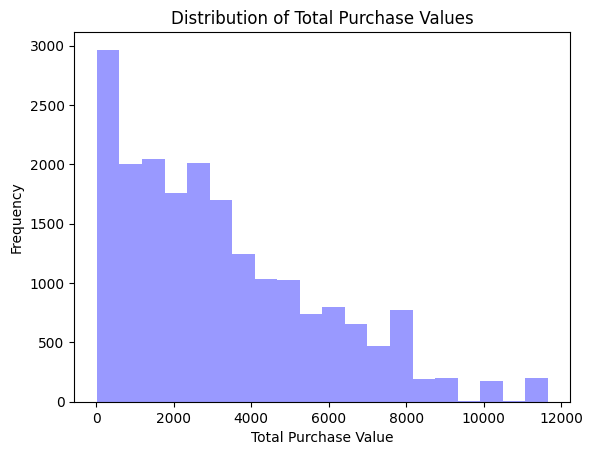

In [10]:
#distribution of total_purchase_Value - Univariate Analysis
sns.distplot(data['Total_Purchase_Value'], bins=20, kde=False, color='blue')
plt.title('Distribution of Total Purchase Values')
plt.xlabel('Total Purchase Value')
plt.ylabel('Frequency')
plt.show()

<h3> Observation - Most of the customers have spent below 2000 USD, while there are few customers who have spend close to 11000 USD.

<h3> Customer Rating Distribution

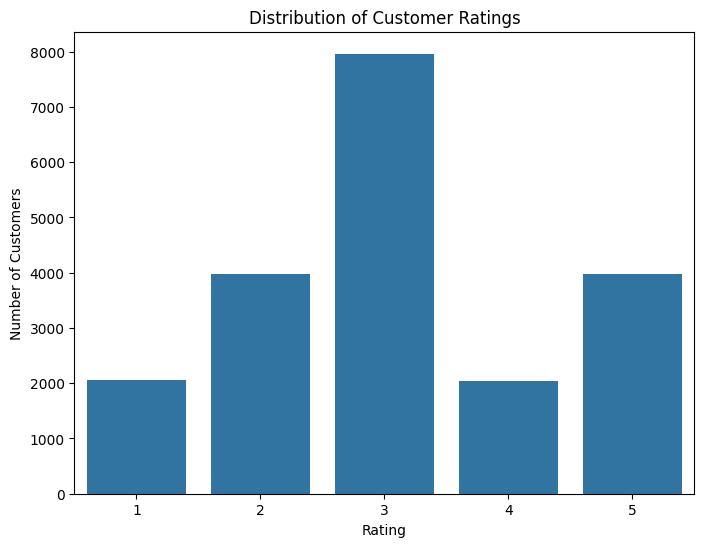

In [69]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Rating', data=data)
plt.title('Distribution of Customer Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Customers')
plt.show()

<h3> Monthwise Total Purchase

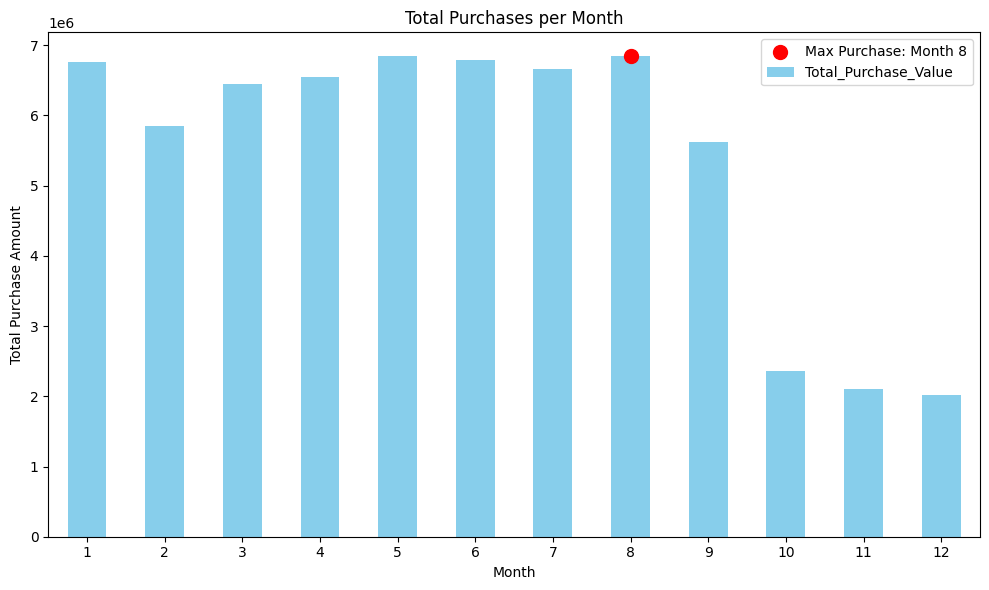

In [11]:
# Convert 'Purchase Date' to datetime
data['Purchase Date'] = pd.to_datetime(data['Purchase Date'])

# Extract the month from the 'Purchase Date' column
data['Month'] = data['Purchase Date'].dt.month

# Group by month and sum the total purchases
monthly_purchases = data.groupby('Month')['Total_Purchase_Value'].sum()

# Find the month with the maximum total purchase
max_purchase_month = monthly_purchases.idxmax()

# Create the plot
plt.figure(figsize=(10, 6))
monthly_purchases.plot(kind='bar', color='skyblue')
plt.title('Total Purchases per Month')
plt.xlabel('Month')
plt.ylabel('Total Purchase Amount')
plt.xticks(rotation=0)  # Rotate x-axis labels for better readability

# Add a marker for the month with the maximum purchase
plt.scatter(max_purchase_month - 1, monthly_purchases.max(), color='red', s=100, label=f'Max Purchase: Month {max_purchase_month}')
plt.legend()
plt.tight_layout()
plt.show()

<h3> Observation - Month 8 (April) is probably the month when most sales
occured. June, July & August are the months when least sales occured. Note, since the data is from Sep'23-Sep'24, Month 1 corresponds to September 2023.

<h3> Total Price spent for different Product Type

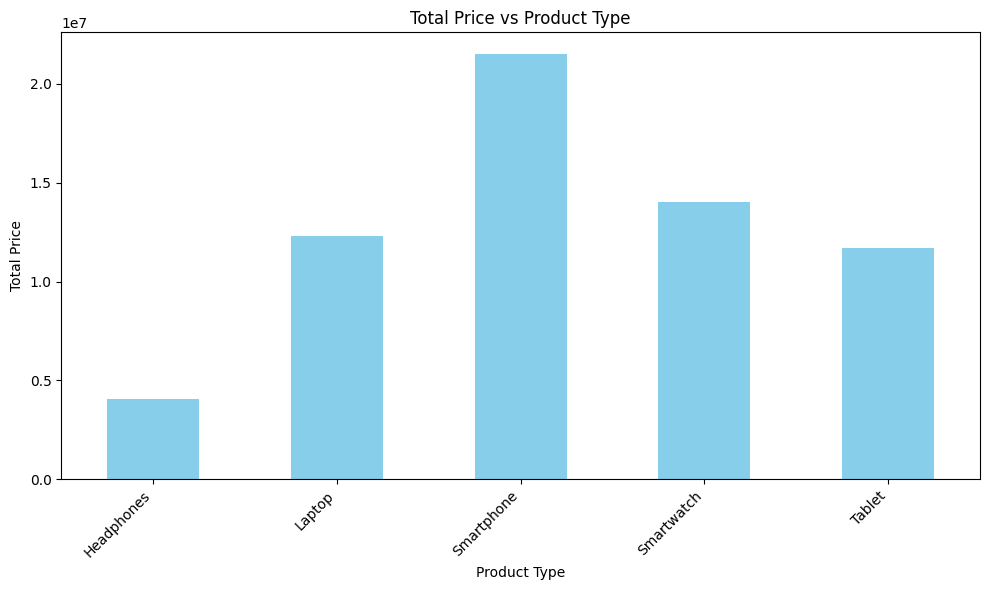

In [12]:
# Group by product type and sum the total price
product_sales = data.groupby('Product Type')['Total Price'].sum()

# Create the bar plot
plt.figure(figsize=(10, 6))
product_sales.plot(kind='bar', color='skyblue')
plt.title('Total Price vs Product Type')
plt.xlabel('Product Type')
plt.ylabel('Total Price')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<h3> Observation - Smartphone product is the category for which customers have paid maximum price and customers have spent the least in Headphones category.

<h3> Word Cloud of Frequently Purchased Add-Ons

In [13]:
l = []
for i in data['Add-ons Purchased'].values:
    try:
       l = l + list(set([i.strip() for i in i.split(",")]))
    except:
        pass


In [14]:
Frequent_addons = Counter(l)

In [15]:
Frequent_addons

Counter({'Accessory': 7980, 'Impulse Item': 8122, 'Extended Warranty': 7971})

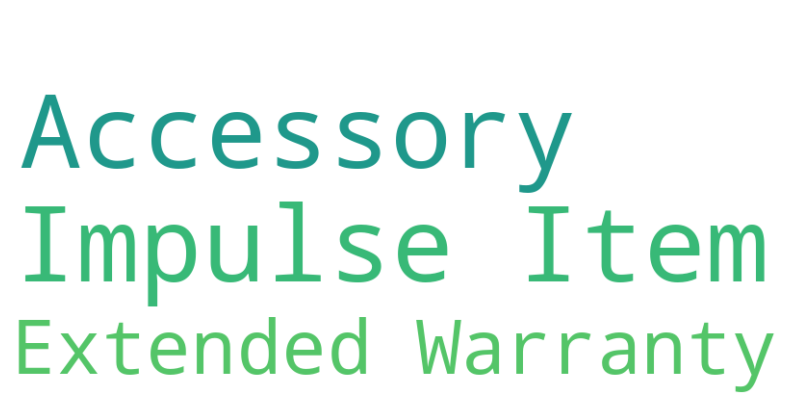

In [16]:
# Create a word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(Frequent_addons)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

<h3> Observation - so, there are just 3 add-ons that are purchased in this period of 1 year. Impulse Item is the most frequently purchased Add-ons by Customer, while Extended Warranty is the least purchased Add-ons

<h3> Pie Chart Representation of payment methods used

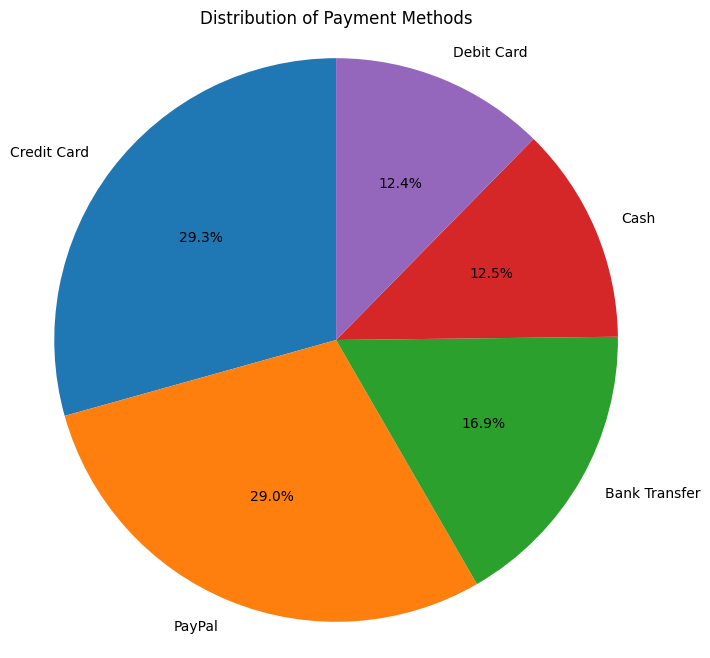

In [17]:
data['Payment Method'] = data['Payment Method'].replace('Paypal', 'PayPal')
payment_counts = data['Payment Method'].value_counts()

# Create the pie chart
plt.figure(figsize=(8, 8))
plt.pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Payment Methods')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

<h3> Observation - Credit Card & PayPal are the most trusted methods of payment while payment in Debit Card & Cash is less common for the customers.

<h3> Total Purchase Price vs Shipping Type

<ipython-input-18-9858d9bbc317>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = data['Shipping Type'],y = data['Total Price'], palette='viridis')


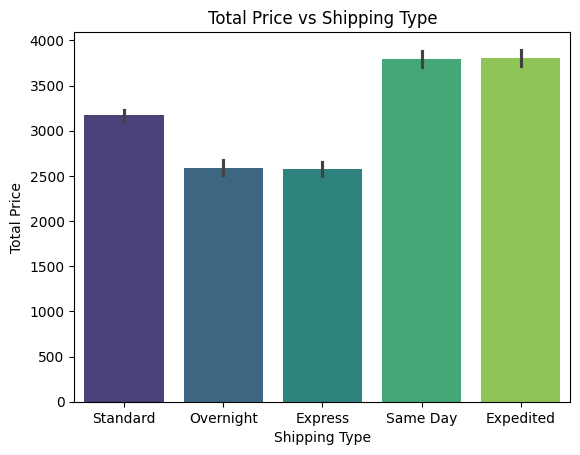

In [18]:
sns.barplot(x = data['Shipping Type'],y = data['Total Price'], palette='viridis')
plt.title('Total Price vs Shipping Type')
plt.xlabel('Shipping Type')
plt.ylabel('Total Price')
plt.show()

<h3> Observation - As the total Price increased, customers generally opted for Same Day or Expedited deliveries.

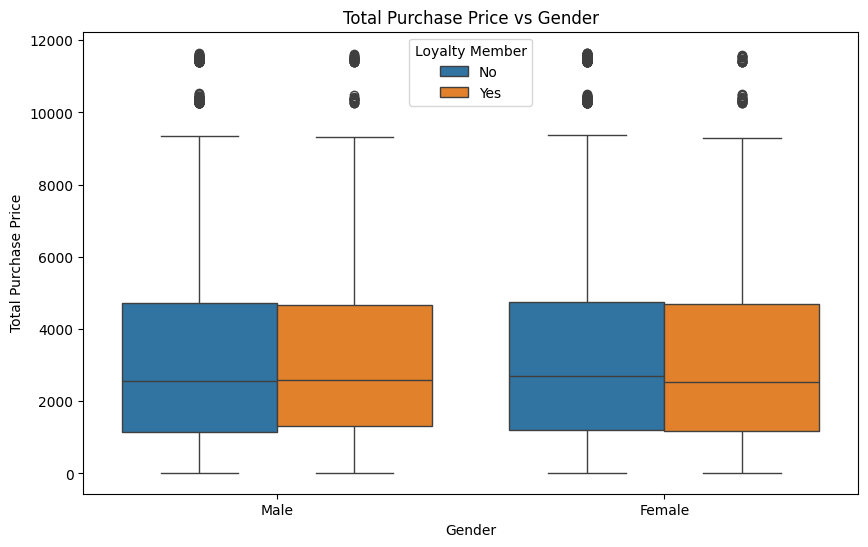

In [19]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Gender', y='Total_Purchase_Value', hue='Loyalty Member', data=data)
plt.title('Total Purchase Price vs Gender')
plt.xlabel('Gender')
plt.ylabel('Total Purchase Price')
plt.show()

<h3> Observation - No significant difference in the distribution of Total Purchase made for the Male & Female Gender. Generally, the median value of the Total purchase is less in case of loyal female members than non-loyal members.

([0, 1, 2, 3],
 [Text(0, 0, 'Teenagers'),
  Text(1, 0, 'Young Adults'),
  Text(2, 0, 'Adults'),
  Text(3, 0, 'Seniors')])

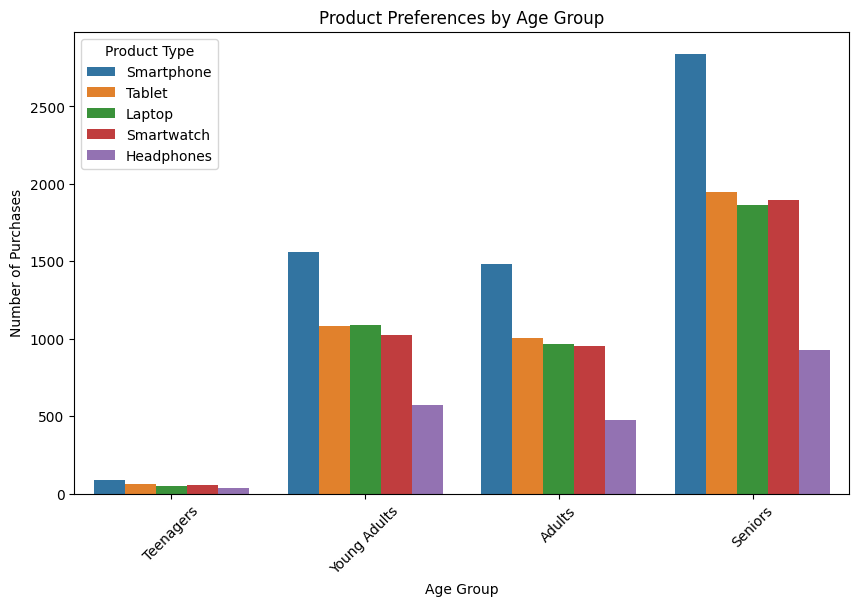

In [20]:
data['Age_Group'] = pd.cut(data['Age'], bins=[0, 18, 35, 50, 100], labels=['Teenagers','Young Adults', 'Adults', 'Seniors'])
plt.figure(figsize=(10, 6))
sns.countplot(x='Age_Group', hue='Product Type', data=data)
plt.title('Product Preferences by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Purchases')
plt.xticks(rotation=45)

<h3> Observation - Age Category (50+) have made the most number of purchases, followed by Adults & Young Adults. Product wise count of Sales remain the same across the 4 age segmentation. Smartphone product type is the most purchased category for all age groups and Headphones product type is the least purchased product type.

<h2> Classification Task- Rating Prediction </h2>

Business Problem Statement: To enhance customer satisfaction and decision-making, we aim to develop a binary classification model that identifies customer sentiment (Positive or Negative) based on review ratings. Reviews rated 1-3 are categorized as Negative (0), while reviews rated 4-5 are categorized as Positive (1). This classification will provide actionable insights into customer feedback and improve overall business strategies.

In [21]:
data['rating_binary'] = pd.cut(data['Rating'], bins=[0, 3, 5], labels=[0, 1])

<h3> Data Preparation </h3>

In [22]:
#We need to one-hot encode our categorical features
categorical_cols = ['Gender', 'Loyalty Member', 'Product Type', 'Payment Method', 'Order Status', 'Shipping Type']

# One-hot encode the specified categorical columns
data = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

In [23]:
data

,Customer ID,Age,SKU,Rating,Total Price,Unit Price,Quantity,Purchase Date,Add-ons Purchased,Add-on Total,...,Product Type_Tablet,Payment Method_Cash,Payment Method_Credit Card,Payment Method_Debit Card,Payment Method_PayPal,Order Status_Completed,Shipping Type_Express,Shipping Type_Overnight,Shipping Type_Same Day,Shipping Type_Standard
0,1000,53,SKU1004,2,5538.33,791.19,7,2024-03-20,"Accessory,Accessory,Accessory",40.21,...,False,False,True,False,False,False,False,False,False,True
1,1000,53,SKU1002,3,741.09,247.03,3,2024-04-20,Impulse Item,26.09,...,True,False,False,False,True,True,False,True,False,False
2,1002,41,SKU1005,3,1855.84,463.96,4,2023-10-17,NaN,0.00,...,False,False,True,False,False,True,True,False,False,False
3,1002,41,SKU1004,2,3164.76,791.19,4,2024-08-09,"Impulse Item,Impulse Item",60.16,...,False,True,False,False,False,True,False,True,False,False
4,1003,75,SKU1001,5,41.50,20.75,2,2024-05-21,Accessory,35.56,...,False,True,False,False,False,True,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19996,27,SMP234,4,6838.08,1139.68,6,2024-06-15,NaN,0.00,...,False,False,False,False,False,True,False,False,False,False
19996,19996,27,LTP123,4,2697.28,674.32,4,2024-07-18,NaN,0.00,...,False,False,True,False,False,False,False,False,False,True
19997,19996,27,HDP456,4,1805.90,361.18,5,2024-08-26,"Impulse Item, Extended Warranty, Accessory",198.98,...,False,False,False,False,False,True,False,False,False,True
19998,19997,27,HDP456,1,2528.26,361.18,7,2024-01-06,"Extended Warranty, Accessory",101.34,...,False,False,False,False,False,False,False,False,False,False


In [34]:
# Prepare data
# The features that will be part of classification task is purely out of domain knowledge
X = data.drop(columns=["Customer ID", "SKU", "Rating", "rating_binary",
       'Quantity', 'Purchase Date', 'Total Price', 'Add-ons Purchased' , 'Add-on Total', 'Age_Group', 'Unit Price'])

y = data["rating_binary"]

#split of data in Train & Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



<h2> Modeling

<h3> Decision Tree - Without HyperParameter Tuning </h3>

In [35]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
accuracy_score(y_test, dt_pred)

0.762

<h3> Optimal Depth - Decision Tree

In [36]:
optimal_depth = {}
for depth in range(2, 25):
    dt = DecisionTreeClassifier(max_depth=depth)
    dt.fit(X_train, y_train)
    y_pred = dt.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    optimal_depth[depth] = accuracy
optimal_depth = {i:j for i, j in sorted(optimal_depth.items(), key = lambda x: x[1], reverse=True) }

In [37]:
optimal_depth

{9: 0.78925,
 10: 0.789,
 5: 0.78875,
 7: 0.78875,
 8: 0.78875,
 6: 0.78775,
 11: 0.78775,
 18: 0.78725,
 4: 0.78675,
 3: 0.7855,
 12: 0.78425,
 2: 0.784,
 13: 0.78375,
 14: 0.78375,
 19: 0.7825,
 20: 0.78225,
 15: 0.7805,
 16: 0.78,
 17: 0.77975,
 21: 0.77625,
 22: 0.76975,
 24: 0.765,
 23: 0.76275}

In [38]:
optimal_dt = DecisionTreeClassifier(max_depth = 9)
optimal_dt.fit(X_train, y_train)
optimal_dt_pred = optimal_dt.predict(X_test)
accuracy_score(y_test, optimal_dt_pred)

0.78975

<h3> Logistic Regression </h3>

In [39]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
accuracy_score(y_test, y_pred)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.765

<h3> Ensemble of the above three method </h3>

In [40]:
#with equal weights to all three models
final_majority_pred = []
for i, j, k in zip(dt_pred, optimal_dt_pred, lr_pred):
     if i + j + k >=2:
        final_majority_pred.append(1)
     else:
        final_majority_pred.append(0)

accuracy_score(y_test, final_majority_pred)

0.789

<h3> Random Forest </h3>

In [41]:
parameters = {"max_depth": range(1, len(X.columns))}
rf = RandomForestClassifier()
grid = GridSearchCV(rf, parameters, cv=5)
grid.fit(X_train, y_train)
print(grid.best_params_)

{'max_depth': 8}


In [43]:
rf = RandomForestClassifier(max_depth=8)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
accuracy_score(y_test, y_pred)

0.791

<h3> Variable Importance </h3>

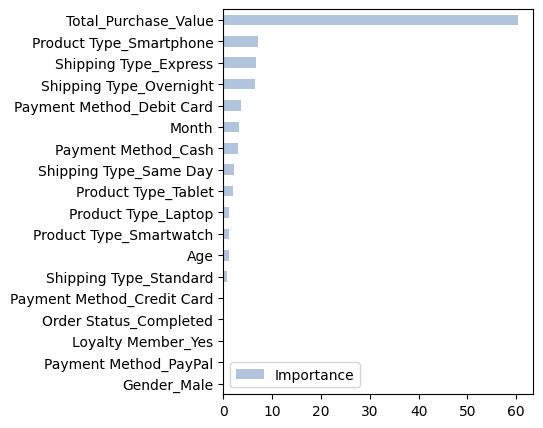

In [44]:
Importance = pd.DataFrame({'Importance':rf.feature_importances_*100}, \
                          index=X_train.columns)
Importance.sort_values('Importance', axis=0, ascending=True).plot(kind='barh', color='lightsteelblue', )
plt.gcf().set_size_inches(4, 5)

<h3> Observation - Total_Purchase_Value, Peoduct_Type_Smartphone, Shipping Type_Express are some of the most important variables in the prediction of the customer ratings

<h3> Shap  Method </h3>

In [45]:
import shap

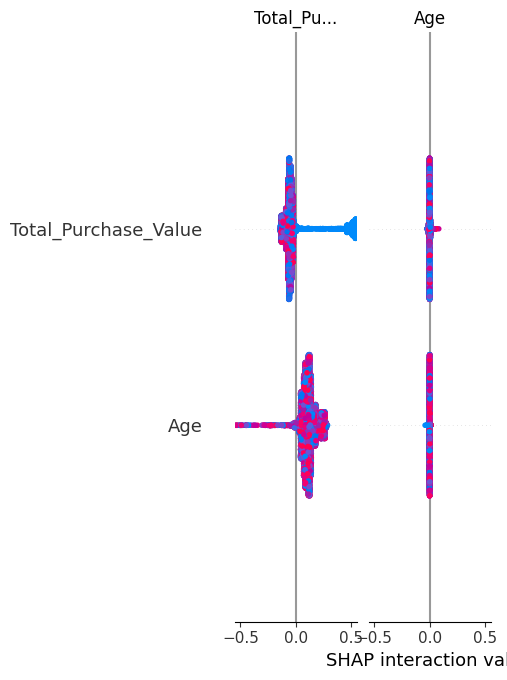

In [46]:
explainer = shap.TreeExplainer(rf)
shap_values=explainer.shap_values(X_train)
expected_value = explainer.expected_value
shap.summary_plot(shap_values, X_train, plot_type="bar")

<h3> Observation - This plot helps identify which feature interactions have a significant impact on the model's predictions, allowing for deeper insights into model behavior and feature relationships. In this case, both Total_Purchase_Value and Age exhibit some interaction effects, but they might not be the strongest drivers of the model's output.

Classification Report

In [66]:
y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.77      1.00      0.87      2765
           1       1.00      0.32      0.49      1235

    accuracy                           0.79      4000
   macro avg       0.88      0.66      0.68      4000
weighted avg       0.84      0.79      0.75      4000



<h3> Observation - From the above classification we can observe that the data set is imbalanced. Precision for Positive Review prdiction is far better than Negative Review Prediction, however, the recall is compromised

ROC Curve

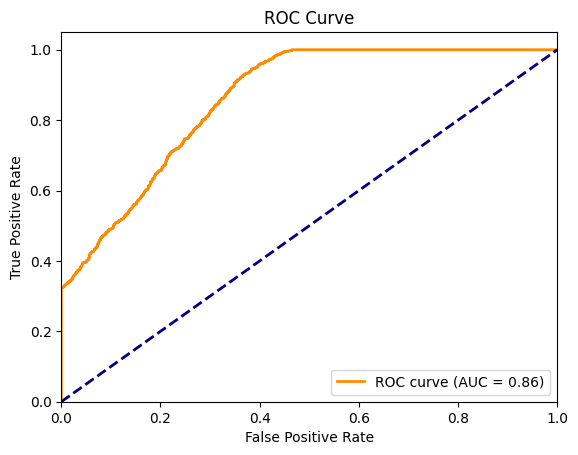

AUC Score: 0.8600291380837684


In [47]:
y_pred_prob = rf.predict_proba(X_test)[:, 1]

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

print(f"AUC Score: {roc_auc}")

<h3> Observation - ROC Curve suggests that model performance of Random Forest is certainly better than a random model with an AUC score of 0.86

<h3> Gains and Lift Chart

In [48]:
rf_predict_prob_test = rf.predict_proba(X_test)[:,1]
df_test =  pd.DataFrame({'prob':rf_predict_prob_test, 'actual':y_test}).reset_index(drop=True)

In [49]:
df_test

,prob,actual
0,0.350956,1
1,0.070559,0
2,0.065625,0
3,0.071596,0
4,0.356069,1
...,...,...
3995,0.060085,0
3996,0.024537,0
3997,0.011463,0
3998,0.929023,1


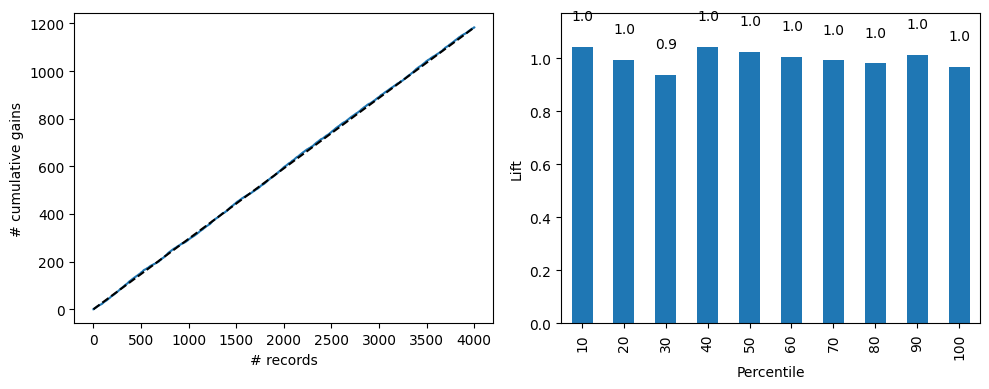

In [61]:
dfgains = df_test.sort_values(by='prob', ascending=False)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

gainsChart(df_test.prob, ax=axes[0])
liftChart(df_test['prob'], title=False, ax=axes[1])

plt.tight_layout()
plt.show()